<a href="https://colab.research.google.com/github/eduardo-illueca/icg-project/blob/main/Detection_ReBeat_v1_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook presents the configuration of the Denoising Autoencoder (v2) and the Characteristic Point Detection Model (v1.3), which incorporates higher noise levels during data augmentation and is designed to detect all four characteristic points (B, C, X, O) from the ICG signal.


#Load data

This code downloads and extracts three datasets from a public Zenodo repository into separate directories in the Colab environment. It first creates folders for raw data, filtered data, and expert annotations, then fetches the corresponding ZIP files from their URLs, saves them locally, and unzips their contents into the appropriate directories for further processing.

In [ ]:
!mkdir /content/RawData/
!wget -q https://zenodo.org/records/4725433/files/01_RawData.zip?download=1 -O /content/RawData/01_RawData.zip
!unzip -qo /content/RawData/01_RawData.zip -d /content/RawData/

!mkdir /content/FilteredData/
!wget -q https://zenodo.org/records/4725433/files/02_FilteredData.zip?download=1 -O /content/FilteredData/02_FilteredData.zip
!unzip -qo /content//FilteredData/02_FilteredData.zip -d /content//FilteredData/

!mkdir /content/Annotations/
!wget -q https://zenodo.org/records/4725433/files/03_ExpertAnnotations.zip?download=1 -O /content/Annotations/02_FilteredData.zip
!unzip -qo /content/Annotations/02_FilteredData.zip -d /content/Annotations/

In [ ]:
import os
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, UpSampling1D, LSTM, Bidirectional, TimeDistributed, Dense
from tensorflow.keras.callbacks import EarlyStopping

from google.colab import files


We load the subjects to create an input for the autoencoder, that needs to be(num_segments, 200, 1).

In [ ]:
# ---- Load subjects and parameters ----
subjects = ['1','2','3','4','5', '6', '7', '8','9','10','11','12','13','14','15','16','17','18','19','20','21','22','23','24']
tasks = ['CW', 'BL']

fs = 250  # Hz
pre_r = int(0.2 * fs)   # 50 samples
post_r = int(0.6 * fs)  # 150 samples
segment_len = pre_r + post_r  # 200 samples

autoencoder_segments = []

for subject in subjects:
    for task in tasks:
        try:
            # ---- Load files ----
            path_filtered = f'/content/FilteredData/FilteredData_Subject_{subject}_task_{task}.mat'
            path_annotation = f'/content/Annotations/Annotat_Subject_{subject}_task_{task}.mat'

            data_filtered = sio.loadmat(path_filtered)
            ecg_filtered = data_filtered['ECG'].squeeze()
            icg_filtered = data_filtered['ICG'].squeeze()

            # ---- Detect R-peaks ----
            r_peaks, _ = find_peaks(ecg_filtered, distance=int(0.6 * fs), height=np.mean(ecg_filtered)) #it works

            # ---- Extract segments around each R-peak ----
            for r in r_peaks:
                start = r - pre_r
                end = r + post_r
                if start < 0 or end > len(icg_filtered):
                    continue
                segment = icg_filtered[start:end]
                if len(segment) != segment_len:
                    continue

                autoencoder_segments.append(segment)

            print(f"Loaded Subject {subject} Task {task}: {len(r_peaks)} R-peaks")

        except Exception as e:
            print(f"Skipping Subject {subject} Task {task}: {e}")

# ---- Final formatting ----
X_auto = np.array(autoencoder_segments)  # shape: (n_samples, 174)

# Normalize each segment individually
X_auto = (X_auto - X_auto.mean(axis=1, keepdims=True)) / (X_auto.std(axis=1, keepdims=True) + 1e-8)

# Add channel dimension for the model: (n_samples, 174, 1)
X_auto = X_auto[..., np.newaxis]

# ---- Save for training the autoencoder ----
np.save("X_icg_autoencoder_input.npy", X_auto)
print(f"\nPrepared {X_auto.shape[0]} segments for autoencoder training.")


Loaded Subject 1 Task CW: 309 R-peaks
Loaded Subject 1 Task BL: 301 R-peaks
Loaded Subject 2 Task CW: 306 R-peaks
Loaded Subject 2 Task BL: 312 R-peaks
Loaded Subject 3 Task CW: 369 R-peaks
Loaded Subject 3 Task BL: 375 R-peaks
Loaded Subject 4 Task CW: 407 R-peaks
Loaded Subject 4 Task BL: 416 R-peaks
Loaded Subject 5 Task CW: 433 R-peaks
Loaded Subject 5 Task BL: 404 R-peaks
Loaded Subject 6 Task CW: 339 R-peaks
Loaded Subject 6 Task BL: 355 R-peaks
Loaded Subject 7 Task CW: 326 R-peaks
Loaded Subject 7 Task BL: 342 R-peaks
Loaded Subject 8 Task CW: 389 R-peaks
Loaded Subject 8 Task BL: 387 R-peaks
Loaded Subject 9 Task CW: 408 R-peaks
Loaded Subject 9 Task BL: 400 R-peaks
Loaded Subject 10 Task CW: 318 R-peaks
Loaded Subject 10 Task BL: 314 R-peaks
Loaded Subject 11 Task CW: 430 R-peaks
Loaded Subject 11 Task BL: 391 R-peaks
Loaded Subject 12 Task CW: 339 R-peaks
Loaded Subject 12 Task BL: 359 R-peaks
Loaded Subject 13 Task CW: 320 R-peaks
Loaded Subject 13 Task BL: 334 R-peaks
Load

In [ ]:
X_auto = np.load("X_icg_autoencoder_input.npy")
print(X_auto.shape)  # (num_segments, 200, 1)

(16953, 200, 1)


# Autoencoder v2

V1 of the autoencoder is not denoising, because input data was too clean,in this version we add some noise to training

In [ ]:
input_shape = (200, 1)

# Encoder
input_sig = Input(shape=input_shape)
x = Conv1D(32, 5, activation='relu', padding='same')(input_sig)
x = MaxPooling1D(2, padding='same')(x)
x = Conv1D(16, 5, activation='relu', padding='same')(x)
x = MaxPooling1D(2, padding='same')(x)
x = Conv1D(8, 3, activation='relu', padding='same')(x)
encoded = MaxPooling1D(2, padding='same')(x)  # Shape: (25, 8)

# Decoder
x = Conv1D(8, 3, activation='relu', padding='same')(encoded)
x = UpSampling1D(2)(x)
x = Conv1D(16, 5, activation='relu', padding='same')(x)
x = UpSampling1D(2)(x)
x = Conv1D(32, 5, activation='relu', padding='same')(x)
x = UpSampling1D(2)(x)
decoded = Conv1D(1, 3, activation='linear', padding='same')(x)

autoencoder = Model(input_sig, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 200, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 200, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 100, 16)        │         2,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 50, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 50, 8)          │           392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 25, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 25, 8)          │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d (UpSampling1D)    │ (None, 50, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 50, 16)         │           656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_1 (UpSampling1D)  │ (None, 100, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 100, 32)        │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling1d_2 (UpSampling1D)  │ (None, 200, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 200, 1)         │            97 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,705 (26.19 KB)

 Trainable params: 6,705 (26.19 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
noise_level = 0.05
X_noisy = X_auto + noise_level * np.random.normal(size=X_auto.shape)

## Train the autoencoder

In [ ]:
# train the model
autoencoder.fit(
    X_noisy, X_auto,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    shuffle=True
)


Epoch 1/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - loss: 0.2103 - val_loss: 0.0126
Epoch 2/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - loss: 0.0185 - val_loss: 0.0072
Epoch 3/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - loss: 0.0111 - val_loss: 0.0051
Epoch 4/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 15s 46ms/step - loss: 0.0092 - val_loss: 0.0042
Epoch 5/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 17s 33ms/step - loss: 0.0079 - val_loss: 0.0039
Epoch 6/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 14s 49ms/step - loss: 0.0075 - val_loss: 0.0034
Epoch 7/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step - loss: 0.0070 - val_loss: 0.0033
Epoch 8/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - loss: 0.0067 - val_loss: 0.0032
Epoch 9/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - loss: 0.0063 - val_loss: 0.0030
Epoch 10/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - loss: 0.0063 - val_loss: 0.0029
Epoch 11/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - loss: 0.0061 - val_loss: 0.0028
Epoch 12/50
239/239 ━━━━━━━━━━━━━━

## Saving autoencoder

In [ ]:
autoencoder.save("autoencoder_icg_v2.h5")

## Using autoencoder

In [ ]:
uploaded = files.upload()
filename = list(uploaded.keys())[0]
autoencoder = load_model(filename)

Saving autoencoder_icg_v2.h5 to autoencoder_icg_v2.h5


## We try the trained autoencoder on unannotated data

Detected 309 R-peaks
Extracted 307 ICG segments
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step


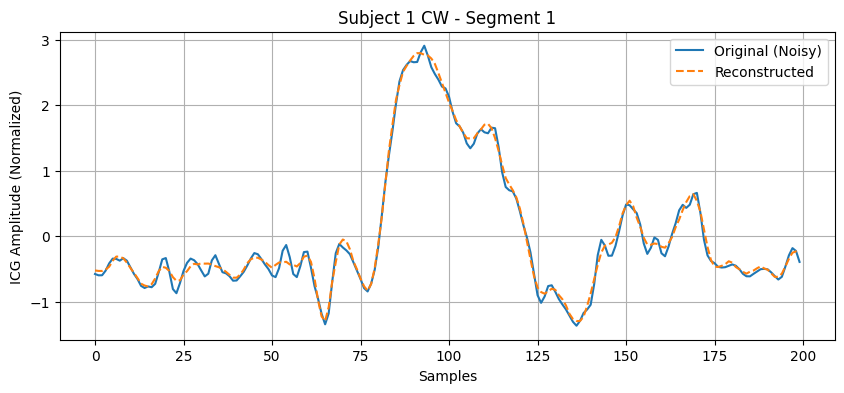

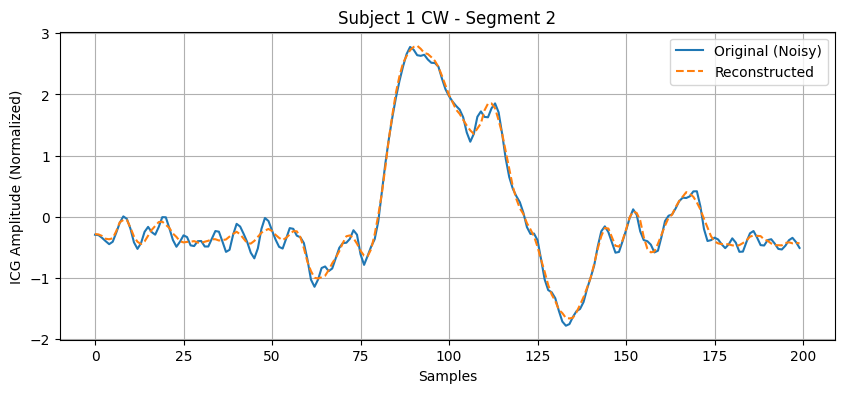

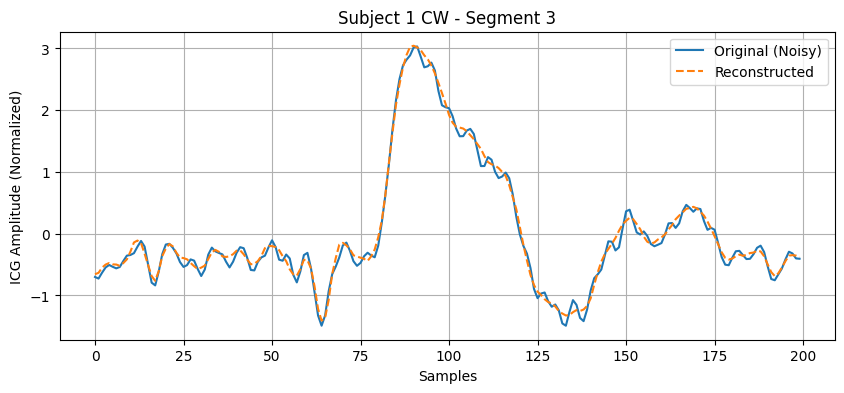

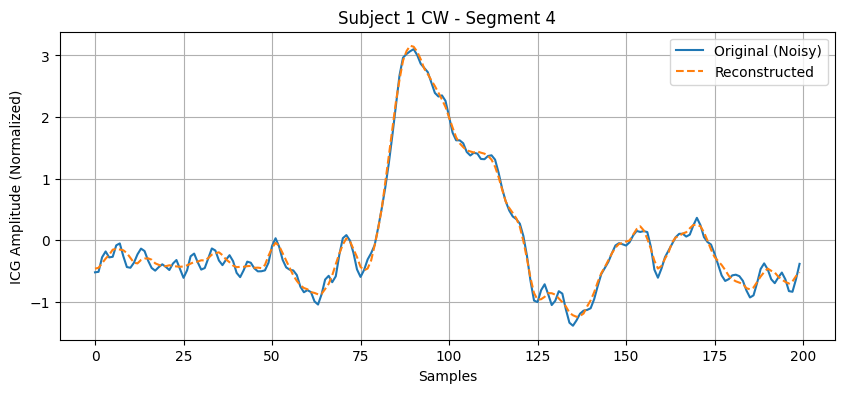

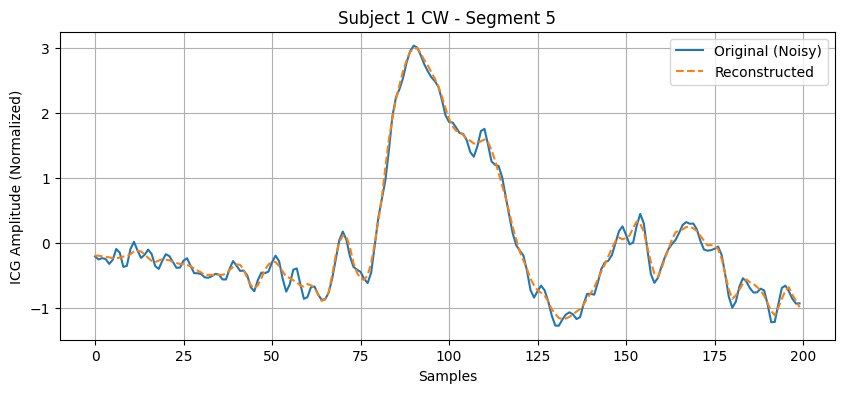

In [ ]:
# ---- Load 1 subject's filtered data ----
subject = '1'
task = 'CW'

data_filtered = sio.loadmat(f'/content/FilteredData/FilteredData_Subject_{subject}_task_{task}.mat')
ecg_filtered = data_filtered['ECG'].squeeze()
icg_filtered = data_filtered['ICG'].squeeze()
fs = int(data_filtered['samplFreq'].squeeze())  # should be 250 Hz

# ---- R-peak detection from ECG ----
distance = int(0.6 * fs)
r_peaks, _ = find_peaks(ecg_filtered, distance=distance, height=np.mean(ecg_filtered))
print(f"Detected {len(r_peaks)} R-peaks")

# ---- Segment ICG using R-peaks ----
pre_r = int(0.2 * fs)
post_r = int(0.6 * fs)
segment_len = pre_r + post_r  # 200 samples total

segments = []
valid_r_peaks = []

for r in r_peaks:
    start = r - pre_r
    end = r + post_r
    if start >= 0 and end < len(icg_filtered):
        segment = icg_filtered[start:end]
        if len(segment) == segment_len:
            segments.append(segment)
            valid_r_peaks.append(r)

print(f"Extracted {len(segments)} ICG segments")

# ---- Prepare segments for the autoencoder ----
X_unlabeled = np.array(segments)
X_unlabeled = (X_unlabeled - X_unlabeled.mean(axis=1, keepdims=True)) / (X_unlabeled.std(axis=1, keepdims=True) + 1e-8)
X_unlabeled = X_unlabeled[..., np.newaxis]  # shape: (n, 200, 1)

# ---- Load the trained autoencoder ----
autoencoder = load_model("autoencoder_icg_v2.h5", compile=False)

# ---- Reconstruct the segments ----
X_reconstructed = autoencoder.predict(X_unlabeled)

# ---- Plot a few input vs reconstructed signals ----
for i in range(5):
    plt.figure(figsize=(10, 4))
    plt.plot(X_unlabeled[i].squeeze(), label='Original (Noisy)')
    plt.plot(X_reconstructed[i].squeeze(), label='Reconstructed', linestyle='--')
    plt.title(f"Subject {subject} {task} - Segment {i+1}")
    plt.xlabel("Samples")
    plt.ylabel("ICG Amplitude (Normalized)")
    plt.legend()
    plt.grid(True)
    plt.show()

We evaluate the denoising performance of an autoencoder by calculating the Signal to Noise Ratio (SNR) between the original and reconstructed signals.

It compares the first 100 segments from the original (X_auto) and reconstructed (X_reconstructed) datasets, then computes the average SNR, which serves as a metric for the quality of the autoencoder’s output. Higher SNR values indicate better denoising performance.



In [ ]:
def snr(original, reconstructed):
    noise = original - reconstructed
    signal_power = np.sum(original ** 2)
    noise_power = np.sum(noise ** 2)
    if noise_power == 0:
        return np.inf  # perfect reconstruction
    return 10 * np.log10(signal_power / noise_power)

X_subset = X_auto[:100].squeeze(axis=-1)         # Shape: (100, 200)
X_recon_subset = X_reconstructed[:100].squeeze(axis=-1)

# Compute SNRs
snrs = [snr(orig, recon) for orig, recon in zip(X_subset, X_recon_subset)]
print(f"Average SNR: {np.mean(snrs):.2f} dB")


Average SNR: 21.20 dB


# Model v3


We add more noise level to help with generalisation.

In [ ]:
# ---- Load subjects and parameters ----
subjects = ['1','2','3','4','5', '6', '7', '8','9','10','11','12','13','14','15','16','17','18','19','20','21','22','23','24']
tasks = ['CW', 'BL']

fs = 250  # Hz
segment_len = 200
pre_r = int(0.2 * fs)   # 0.2s before R = 50 samples
post_r = int(0.6 * fs)  # 0.6s after R = 150 samples

all_segments = []
all_labels = []

for subject in subjects:
    for task in tasks:
        try:
            # ---- Load files ----
            path_filtered = f'/content/FilteredData/FilteredData_Subject_{subject}_task_{task}.mat'
            path_annotation = f'/content/Annotations/Annotat_Subject_{subject}_task_{task}.mat'

            data_filtered = sio.loadmat(path_filtered)
            annotation = sio.loadmat(path_annotation)

            ecg_filtered = data_filtered['ECG'].squeeze()
            icg_filtered = data_filtered['ICG'].squeeze()
            annotations = annotation['annotPoints']

            # ---- Detect R-peaks ----
            r_peaks, _ = find_peaks(ecg_filtered, distance=int(0.6 * fs), height=np.mean(ecg_filtered))

            for r in r_peaks:
                start = r - pre_r
                end = r + post_r
                if start < 0 or end > len(icg_filtered):
                    continue

                icg_segment = icg_filtered[start:end]
                ecg_segment = ecg_filtered[start:end]

                if len(icg_segment) != segment_len or len(ecg_segment) != segment_len:
                    continue

                segment = np.stack((icg_segment, ecg_segment), axis=-1)  # Shape: [200, 2]

                for row in annotations:
                    b, c, x, o = row
                    if start <= b and o <= end:
                        relative = [b - start, c - start, x - start, o - start]
                        all_segments.append(segment)
                        all_labels.append(relative)
                        break  # avoid duplicates

            print(f"Loaded Subject {subject} Task {task}: {len(annotations)} annotations")

        except Exception as e:
            print(f"Skipping Subject {subject} Task {task}: {e}")

# ---- Final formatting ----
X = np.array(all_segments)  # shape: (n_samples, 200, 2)
y = np.array(all_labels)    # shape: (n_samples, 4)

# ---- Normalize per channel per sample ----
X_mean = X.mean(axis=1, keepdims=True)
X_std = X.std(axis=1, keepdims=True) + 1e-8
X = (X - X_mean) / X_std

# ---- One-hot encode labels ----
n_samples = y.shape[0]
n_classes = 4  # B, C, X, O
y_onehot = np.zeros((n_samples, segment_len, n_classes), dtype=np.float32)

for i in range(n_samples):
    for class_idx, t in enumerate(y[i]):
        if 0 <= t < segment_len:
            y_onehot[i, t, class_idx] = 1.0

# ---- Save everything ----
np.save("X_icg_ecg_segments.npy", X)           # [n_samples, 200, 2]
np.save("y_icg_labels_original.npy", y)        # [n_samples, 4]
np.save("y_icg_labels_onehot.npy", y_onehot)   # [n_samples, 200, 4]

# ---- Preview ----
df_preview = pd.DataFrame(y[:10], columns=["B", "C", "X", "O"])
print("\nSample annotation preview (relative to R-aligned segment):")
print(df_preview)

# ---- Plot one-hot labels for a sample ----
sample_index = 0
labels = ["B", "C", "X", "O"]
time_steps = np.arange(segment_len)
time_ms = (time_steps - pre_r) * 1000 / fs  # Centered at R-peak

# plt.figure(figsize=(12, 3))
# for i in range(n_classes):
#     plt.plot(time_ms, y_onehot[sample_index, :, i], label=labels[i])
# plt.title("One-hot encoded labels (Sample 0)")
# plt.xlabel("Time (ms relative to R-peak)")
# plt.ylabel("Label")
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

Loaded Subject 1 Task CW: 40 annotations
Loaded Subject 1 Task BL: 40 annotations
Loaded Subject 2 Task CW: 39 annotations
Loaded Subject 2 Task BL: 40 annotations
Loaded Subject 3 Task CW: 40 annotations
Loaded Subject 3 Task BL: 40 annotations
Loaded Subject 4 Task CW: 40 annotations
Loaded Subject 4 Task BL: 40 annotations
Skipping Subject 5 Task CW: [Errno 2] No such file or directory: '/content/Annotations/Annotat_Subject_5_task_CW.mat'
Loaded Subject 5 Task BL: 71 annotations
Loaded Subject 6 Task CW: 40 annotations
Loaded Subject 6 Task BL: 39 annotations
Loaded Subject 7 Task CW: 40 annotations
Loaded Subject 7 Task BL: 40 annotations
Loaded Subject 8 Task CW: 40 annotations
Loaded Subject 8 Task BL: 40 annotations
Loaded Subject 9 Task CW: 40 annotations
Loaded Subject 9 Task BL: 40 annotations
Loaded Subject 10 Task CW: 40 annotations
Loaded Subject 10 Task BL: 40 annotations
Loaded Subject 11 Task CW: 40 annotations
Loaded Subject 11 Task BL: 40 annotations
Loaded Subject 12

We use data augmentation to improve model robustness during training. For each input sample, we use 3 types of random transformations:

(1) Gaussian noise is added to simulate measurement variability

(2) Amplitude scaling randomly adjusts the signal's magnitude to mimic physiological differences

(3) Time shifting the signal left or right by a few samples to increase temporal tolerance.

In [ ]:
def augment_batch(X, y, noise_std=0.1, amp_range=(0.9, 1.1), max_shift=2):
    X_aug = np.copy(X)
    y_aug = np.copy(y)

    for i in range(X.shape[0]):
        # --- Gaussian noise ---
        X_aug[i] += np.random.normal(0, noise_std, size=X[i].shape)

        # --- Amplitude scaling ---
        scale = np.random.uniform(*amp_range)
        X_aug[i] *= scale

        # --- Time shift ---
        shift = np.random.randint(-max_shift, max_shift + 1)
        if shift != 0:
            X_aug[i] = np.roll(X_aug[i], shift, axis=0)
            y_aug[i] = np.roll(y_aug[i], shift, axis=0)
            if shift > 0:
                y_aug[i, :shift] = 0
            else:
                y_aug[i, shift:] = 0

    return X_aug, y_aug


In [ ]:
def build_model(input_shape=(200, 2), num_classes=4):
    inputs = Input(shape=input_shape)

    x = Conv1D(64, kernel_size=5, padding='same', activation='relu')(inputs)
    x = Conv1D(128, kernel_size=5, padding='same', activation='relu')(x)
    x = Bidirectional(LSTM(32, return_sequences=True))(x)
    x = TimeDistributed(Dense(64, activation='relu'))(x)
    outputs = TimeDistributed(Dense(num_classes, activation='softmax'))(x)

    model = Model(inputs, outputs)
    return model

In [ ]:
# Load data
X = np.load("X_icg_ecg_segments.npy")           # (n_samples, 200, 2)
y = np.load("y_icg_labels_onehot.npy")          # (n_samples, 200, 4)

# Split (simple example)
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Build model
model = build_model(input_shape=(200, 2), num_classes=4)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Augment training data
X_train_aug, y_train_aug = augment_batch(X_train, y_train)

## Training

In [ ]:
# ---- Early stopping callback ----
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Train
history = model.fit(
    X_train_aug, y_train_aug,
    validation_data=(X_val, y_val),
    epochs=30,
    callbacks=[early_stopping],
    batch_size=32
)

Epoch 1/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 52s 535ms/step - accuracy: 0.0681 - loss: 0.0164 - val_accuracy: 0.1269 - val_loss: 0.0026
Epoch 2/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 36s 424ms/step - accuracy: 0.2054 - loss: 0.0019 - val_accuracy: 0.3461 - val_loss: 0.0013
Epoch 3/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 18s 379ms/step - accuracy: 0.3680 - loss: 0.0012 - val_accuracy: 0.3657 - val_loss: 0.0011
Epoch 4/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 22s 404ms/step - accuracy: 0.3540 - loss: 9.5338e-04 - val_accuracy: 0.3399 - val_loss: 0.0011
Epoch 5/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 17s 376ms/step - accuracy: 0.3412 - loss: 0.0011 - val_accuracy: 0.2711 - val_loss: 0.0010
Epoch 6/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 17s 377ms/step - accuracy: 0.3027 - loss: 0.0011 - val_accuracy: 0.3055 - val_loss: 9.1804e-04
Epoch 7/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 18s 397ms/step - accuracy: 0.3125 - loss: 7.6565e-04 - val_accuracy: 0.2646 - val_loss: 9.2547e-04
Epoch 8/30
46/46 ━━━━━━━━━━━━━━━━━━━━ 20s 387ms/step - accuracy: 0.3297 - loss: 8

## Using the model

In [ ]:
model.save('icg_detector_v22.h5')

In [ ]:
def extract_predicted_points(y_pred):
    """
    Input:
        y_pred: np.array of shape (n_samples, 200, 4) with softmax outputs
    Returns:
        pred_points: np.array of shape (n_samples, 4), time indices of B, C, X, O
    """
    return np.argmax(y_pred, axis=1)  # shape: (n_samples, 4)


In [ ]:
model = load_model('icg_detector_v22.h5')

y_pred = model.predict(X_val)  # shape: (n_samples, 200, 4)
predicted_points = extract_predicted_points(y_pred)

12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 524ms/step


In [ ]:
def plot_prediction_vs_true(X_sample, y_true_onehot, y_pred_onehot, sample_index=0, fs=250, pre_r=50):
    """
    Visualizes true vs predicted labels on top of ICG signal
    """
    signal = X_sample[sample_index, :, 0]  # ICG signal
    time_steps = np.arange(signal.shape[0])
    time_ms = (time_steps - pre_r) * 1000 / fs

    true_points = np.argmax(y_true_onehot[sample_index], axis=1)
    pred_points = np.argmax(y_pred_onehot[sample_index], axis=1)

    labels = ["B", "C", "X", "O"]
    colors = ["blue", "orange", "green", "red"]

    plt.figure(figsize=(12, 4))
    plt.plot(time_ms, signal, label='ICG signal', color='black', linewidth=1)

    for class_id in range(4):
        true_t = np.argmax(y_true_onehot[sample_index, :, class_id])
        pred_t = np.argmax(y_pred_onehot[sample_index, :, class_id])

        plt.axvline((true_t - pre_r) * 1000 / fs, color=colors[class_id], linestyle='--', label=f'True {labels[class_id]}')
        plt.axvline((pred_t - pre_r) * 1000 / fs, color=colors[class_id], linestyle='-', alpha=0.6, label=f'Pred {labels[class_id]}')

    plt.title(f"Sample {sample_index}: True vs Predicted Characteristic Points")
    plt.xlabel("Time (ms relative to R-peak)")
    plt.ylabel("ICG amplitude (normalized)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


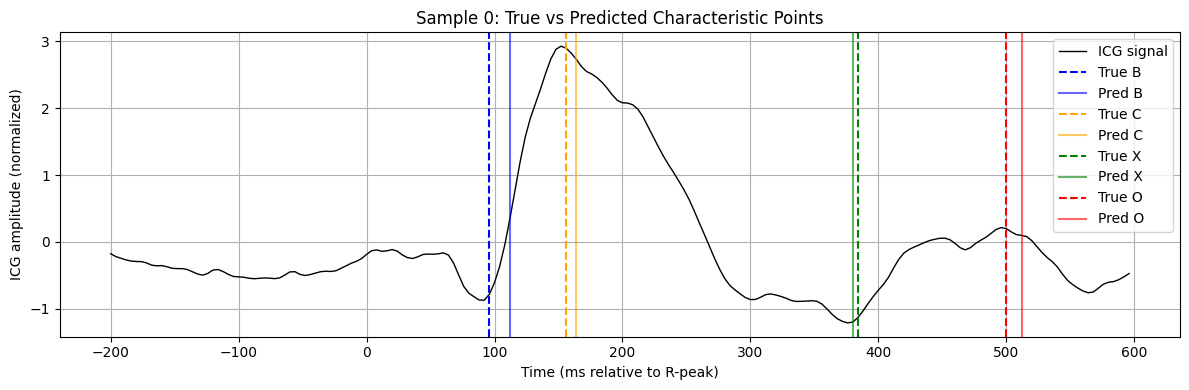

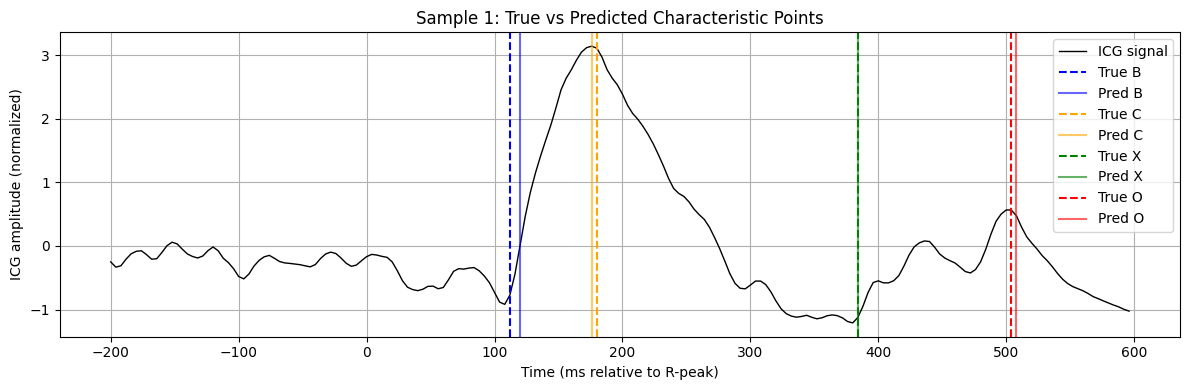

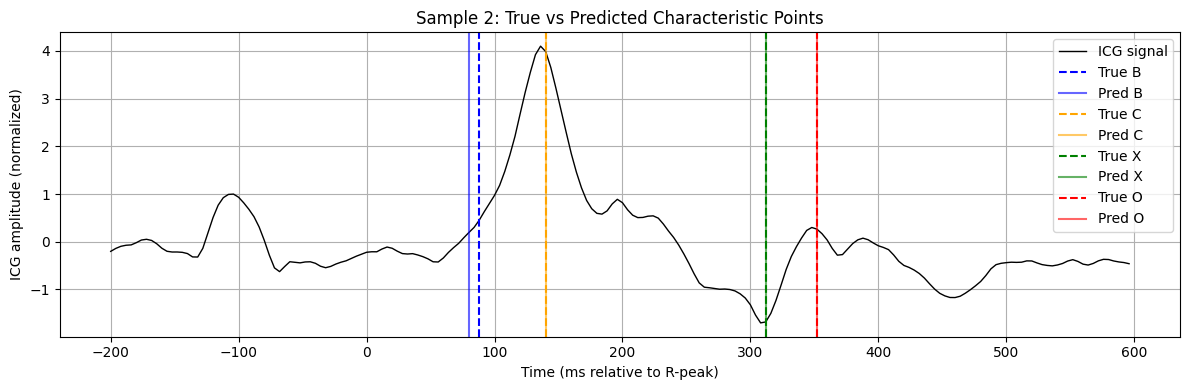

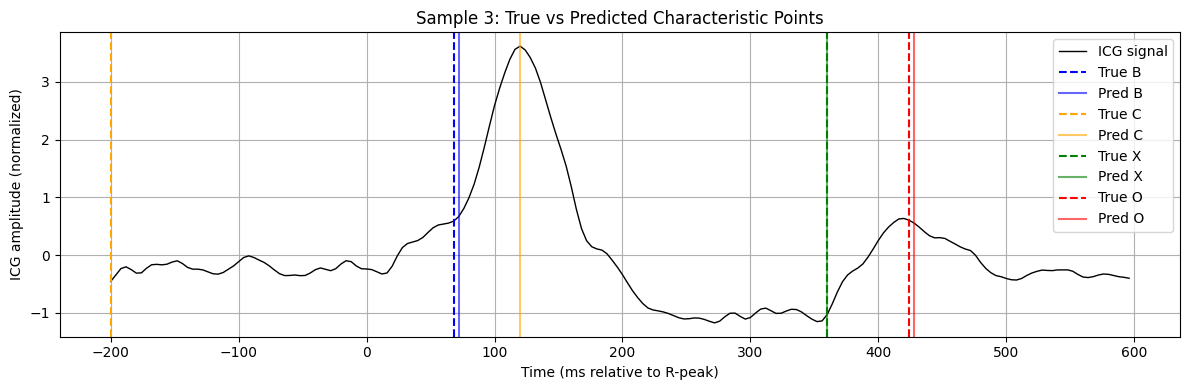

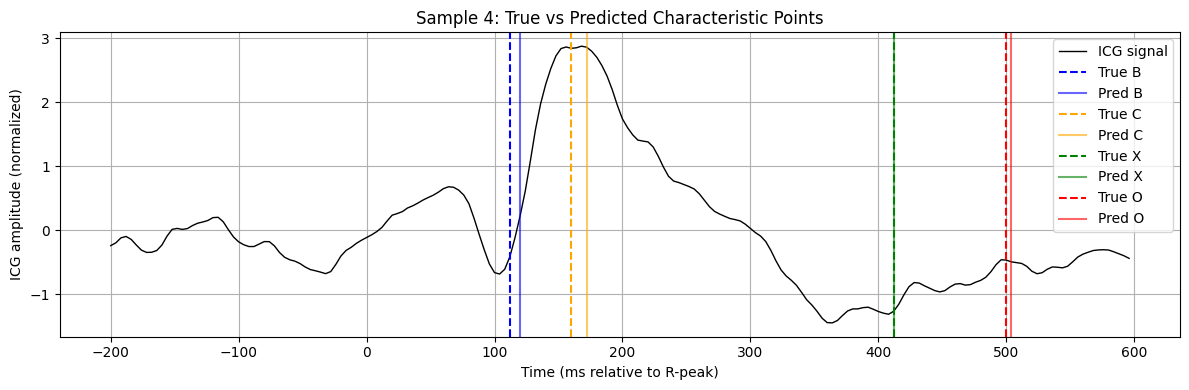

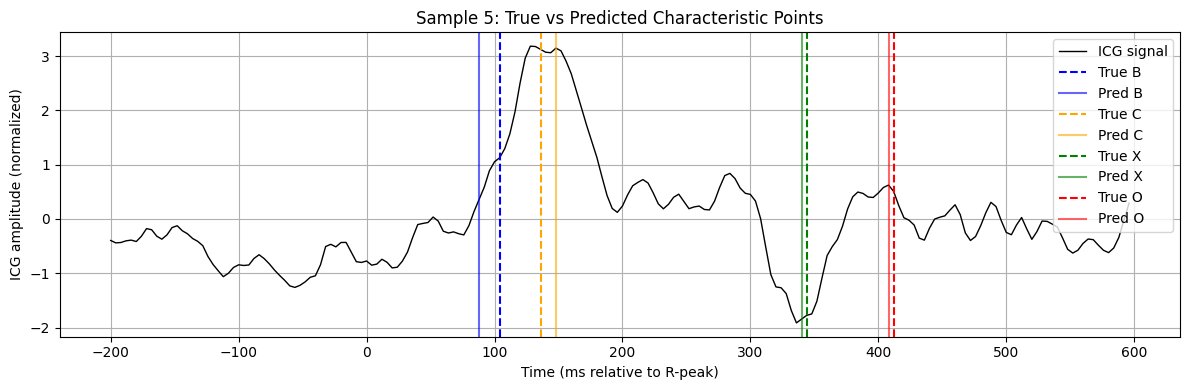

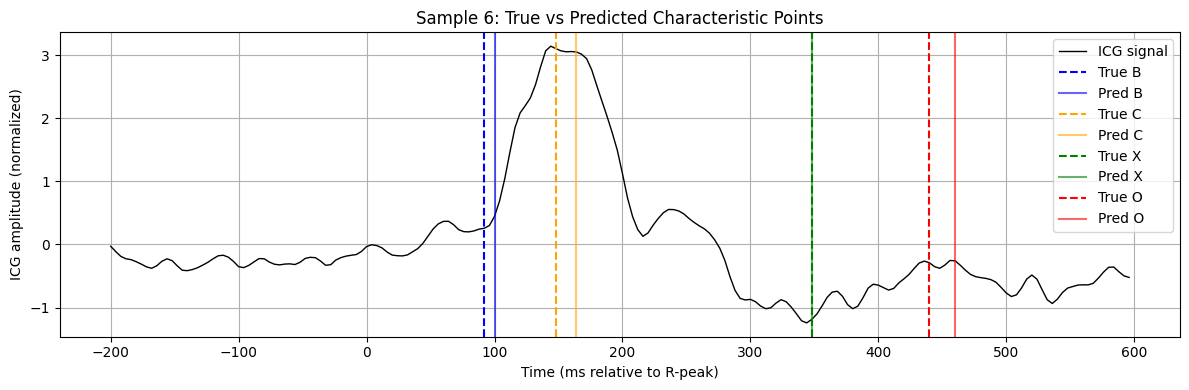

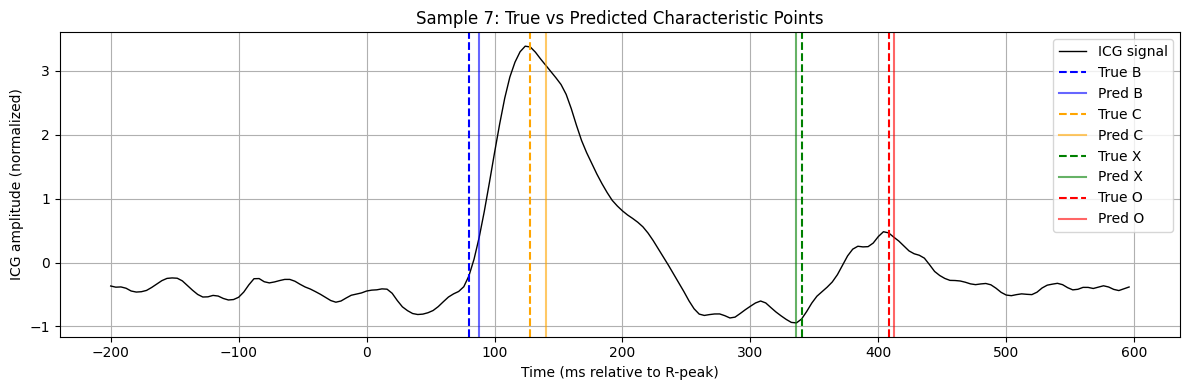

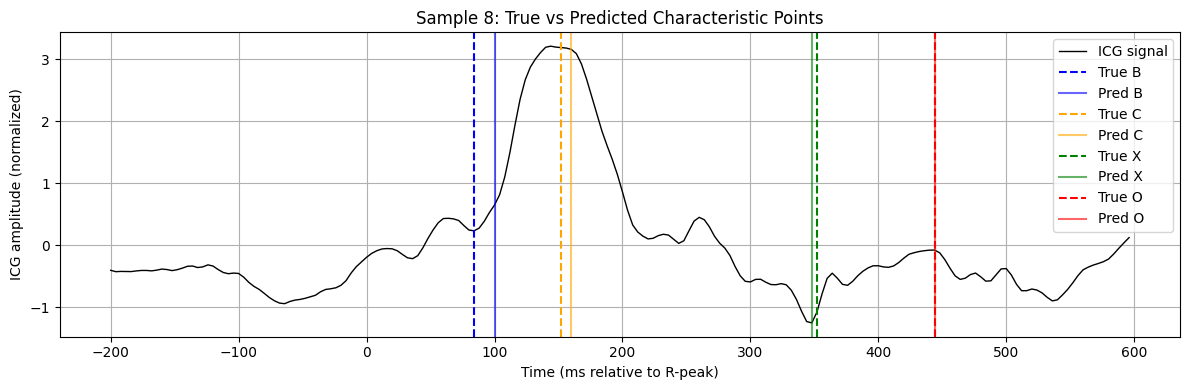

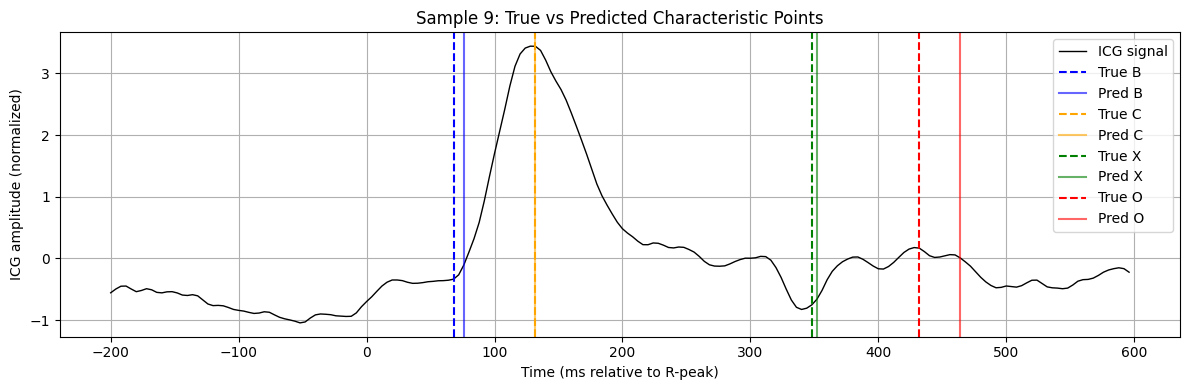

In [ ]:
for i in range(0,10):
  plot_prediction_vs_true(X_val, y_val, y_pred, sample_index=i)


### We evaluate the model's performance

Mean Absolute Error (MAE) measures, on average, how far the model's predictions are from the true values, ignoring the direction.

In [ ]:
def compute_point_errors(y_true_onehot, y_pred_softmax, fs=250, unit="samples"):
    """
    Computes absolute error for each point type (B, C, X, O).

    Parameters:
        y_true_onehot: np.array of shape (n_samples, 200, 4) - one-hot true labels
        y_pred_softmax: np.array of shape (n_samples, 200, 4) - softmax predictions
        fs: sampling frequency in Hz (default = 250)
        unit: 'samples' or 'ms' (default = 'samples')

    Returns:
        A dictionary with mean absolute error for each point (and overall mean).
    """
    y_true_idx = np.argmax(y_true_onehot, axis=1)  # (n_samples, 4)
    y_pred_idx = np.argmax(y_pred_softmax, axis=1) # (n_samples, 4)

    sample_diff = np.abs(y_pred_idx - y_true_idx)

    if unit == "ms":
        diff = (sample_diff * 1000) / fs
    else:
        diff = sample_diff

    labels = ['B', 'C', 'X', 'O']
    errors = {lbl: diff[:, i].mean() for i, lbl in enumerate(labels)}
    errors['mean'] = diff.mean()

    return errors


In [ ]:
y_pred = model.predict(X_val)  # shape: (n_samples, 200, 4)
errors = compute_point_errors(y_val, y_pred, fs=250, unit="samples")
for point, err in errors.items():
    print(f"{point} point error: {err:.2f} samples")


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step
B point error: 4.53 samples
C point error: 4.33 samples
X point error: 2.54 samples
O point error: 5.83 samples
mean point error: 4.31 samples


The mean point error is within 5 samples.

In [ ]:
files.download("icg_detector_v3.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Evaluation on unannotated data

Detected 297 R-peaks
Extracted 295 segments
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step   
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step


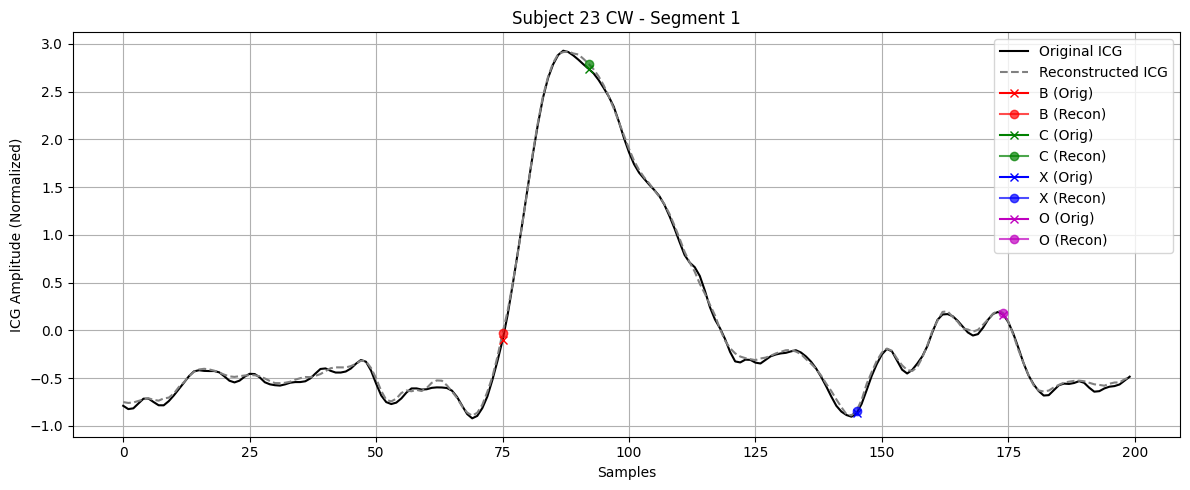

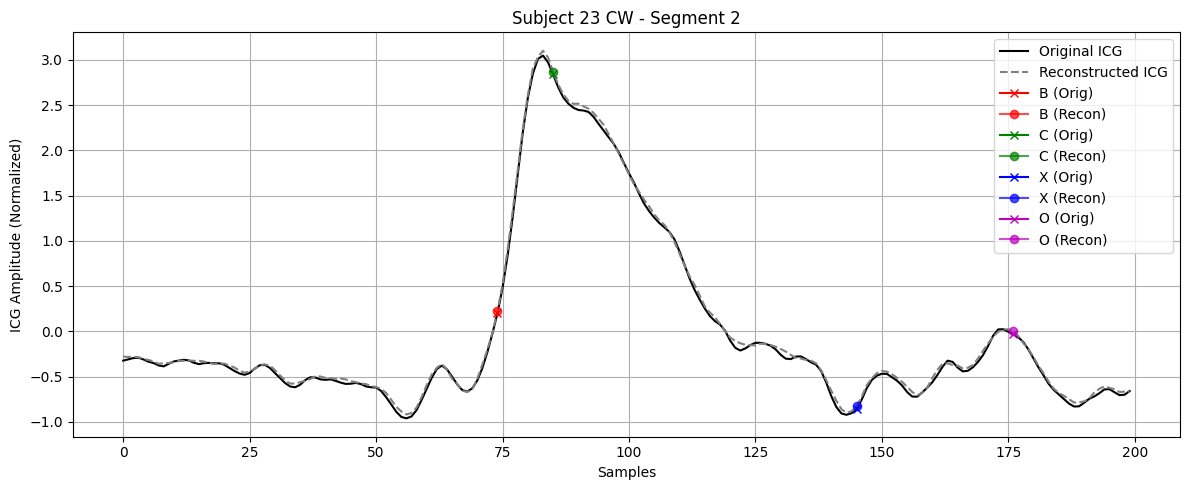

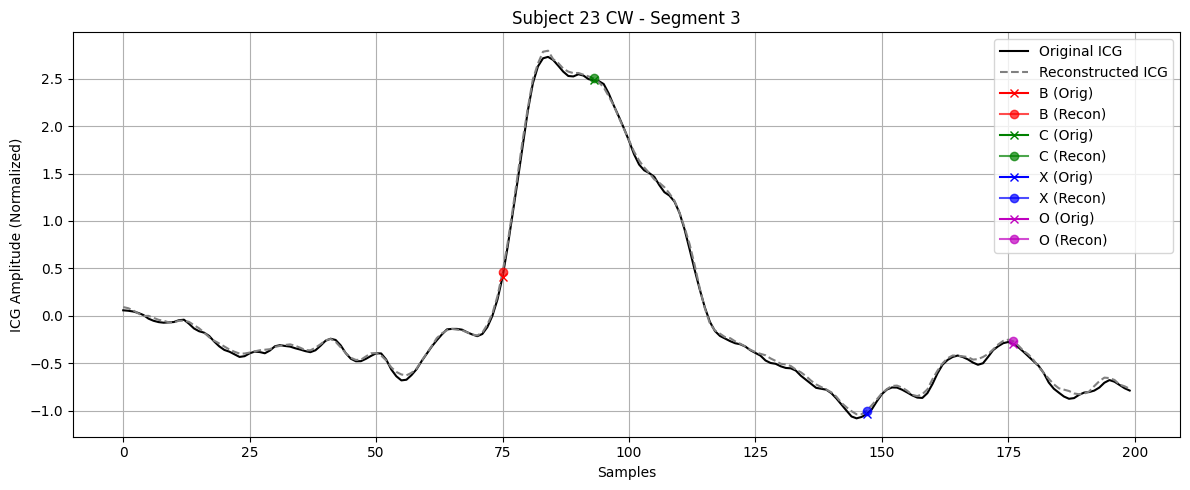

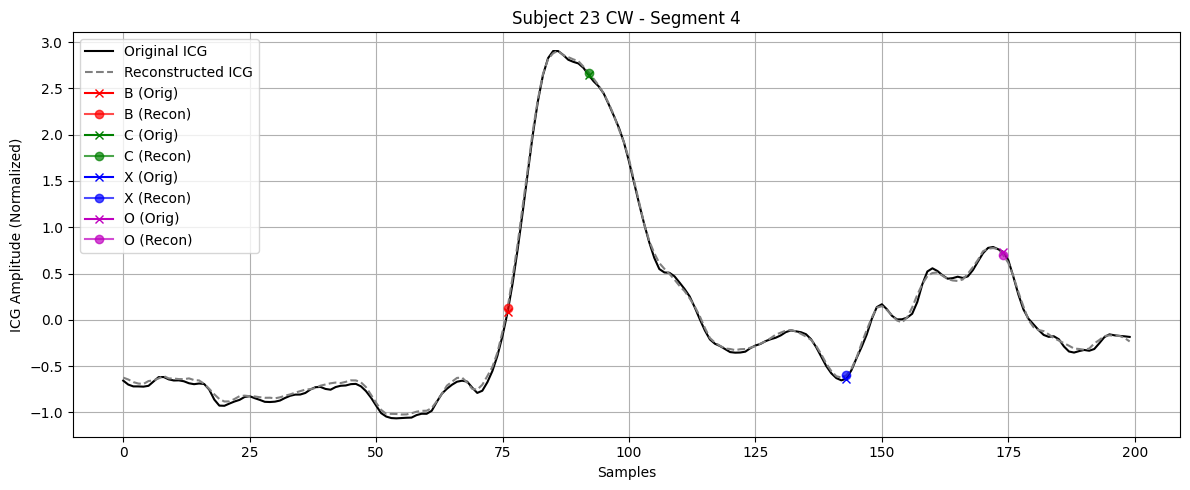

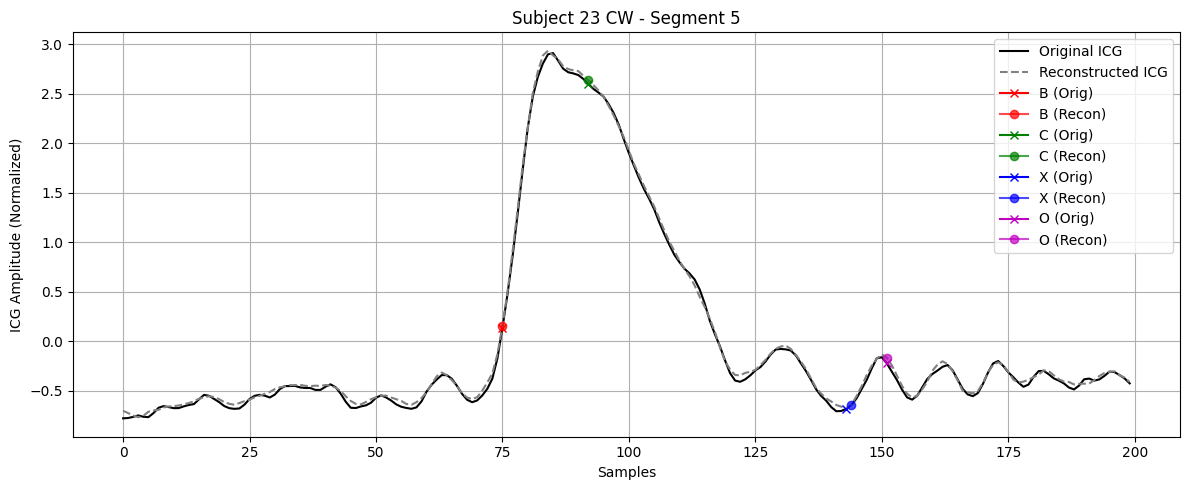

In [ ]:
# ---- Load data ----
subject = '23'
task = 'CW'

data_filtered = sio.loadmat(f'/content/FilteredData/FilteredData_Subject_{subject}_task_{task}.mat')
ecg_filtered = data_filtered['ECG'].squeeze()
icg_filtered = data_filtered['ICG'].squeeze()
fs = int(data_filtered['samplFreq'].squeeze())  # 250 Hz

# ---- R-peak detection ----
r_peaks, _ = find_peaks(ecg_filtered, distance=int(0.6 * fs), height=np.mean(ecg_filtered))
print(f"Detected {len(r_peaks)} R-peaks")

# ---- Segment ICG and ECG ----
pre_r = int(0.2 * fs)
post_r = int(0.6 * fs)
segment_len = pre_r + post_r

icg_segments = []
ecg_segments = []
valid_r_peaks = []

for r in r_peaks:
    start = r - pre_r
    end = r + post_r
    if start >= 0 and end < len(icg_filtered):
        icg_seg = icg_filtered[start:end]
        ecg_seg = ecg_filtered[start:end]
        if len(icg_seg) == segment_len and len(ecg_seg) == segment_len:
            icg_segments.append(icg_seg)
            ecg_segments.append(ecg_seg)
            valid_r_peaks.append(r)

print(f"Extracted {len(icg_segments)} segments")

# ---- Normalize ICG + ECG ----
X_icg = np.array(icg_segments)
X_icg_norm = (X_icg - X_icg.mean(axis=1, keepdims=True)) / (X_icg.std(axis=1, keepdims=True) + 1e-8)
X_icg_norm = X_icg_norm[..., np.newaxis]  # (n, 200, 1)

X_ecg = np.array(ecg_segments)
X_ecg_norm = (X_ecg - X_ecg.mean(axis=1, keepdims=True)) / (X_ecg.std(axis=1, keepdims=True) + 1e-8)
X_ecg_norm = X_ecg_norm[..., np.newaxis]  # (n, 200, 1)

# ---- Reconstruct ICG ----
autoencoder = load_model("autoencoder_icg_v2.h5", compile=False)
X_icg_recon = autoencoder.predict(X_icg_norm)

# ---- Build model inputs ----
X_original_input = np.concatenate([X_icg_norm, X_ecg_norm], axis=-1)
X_recon_input = np.concatenate([X_icg_recon, X_ecg_norm], axis=-1)

# ---- Load detector and predict both ----
detector = load_model("icg_detector_v21.h5", compile=False)

y_pred_orig = detector.predict(X_original_input)
y_pred_recon = detector.predict(X_recon_input)

pred_idx_orig = np.argmax(y_pred_orig, axis=1)   # (n, 4)
pred_idx_recon = np.argmax(y_pred_recon, axis=1) # (n, 4)

# ---- Compare visually ----
labels = ['B', 'C', 'X', 'O']
colors = ['r', 'g', 'b', 'm']

for i in range(min(5, len(X_icg))):
    orig_icg = X_icg_norm[i].squeeze()
    recon_icg = X_icg_recon[i].squeeze()
    pred_o = pred_idx_orig[i]
    pred_r = pred_idx_recon[i]

    plt.figure(figsize=(12, 5))
    plt.plot(orig_icg, label='Original ICG', color='black')
    plt.plot(recon_icg, label='Reconstructed ICG', color='gray', linestyle='--')

    for idx_o, idx_r, lbl, col in zip(pred_o, pred_r, labels, colors):
        if 0 <= idx_o < len(orig_icg):
            plt.plot(idx_o, orig_icg[idx_o], marker='x', color=col, label=f'{lbl} (Orig)')
        if 0 <= idx_r < len(recon_icg):
            plt.plot(idx_r, recon_icg[idx_r], marker='o', color=col, alpha=0.7, label=f'{lbl} (Recon)')

    plt.title(f"Subject {subject} {task} - Segment {i+1}")
    plt.xlabel("Samples")
    plt.ylabel("ICG Amplitude (Normalized)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


The predictions on the original and autoencoder-denoised ICG signals are nearly identical, suggesting that the autoencoder does not significantly alter the morphology of the signal and might not be essential for point detection in this case. This indicates that the original signal quality is already high enough for reliable analysis, or that the model is robust to small variations removed by the autoencoder.

Additionally, the predicted characteristic points appear physiologically plausible. For example, point B occurs just before the steep rise in the ICG signal, consistent with the onset of systole. Point C aligns with the peak of the waveform, representing maximum aortic flow. Point X is correctly placed at the onset of the rapid downward slope, marking aortic valve closure, and point O follows in the diastolic region.